Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°5**
##**Tema**: Aplicaciones de AG##

Objetivo: Aplicar heurísticas a problemas reales.

Integrantes
Carlino Luciano
Di Pietro Luciano

## Ejercicio 1

Utilice el AG Simple para resolver el problema del viajante o TSP (Travelling Salesman Problem):
* Se tienen **N** ciudades por las cuales el viajante debe pasar.
* El viajante pasa sólo una vez por cada ciudad.
* Inicia en una ciudad, hace su recorrido y vuelve a la ciudad de inicio.
* El objetivo es encontrar el camino más corto que el viajante debe recorrer para pasar por todas las ciudades.

El caso particular que usted debe resolver consiste de 14 ciudades, cuyas coordenadas son las siguientes (tomar la primera como punto de partida):

Ciudades para el problema de TSP


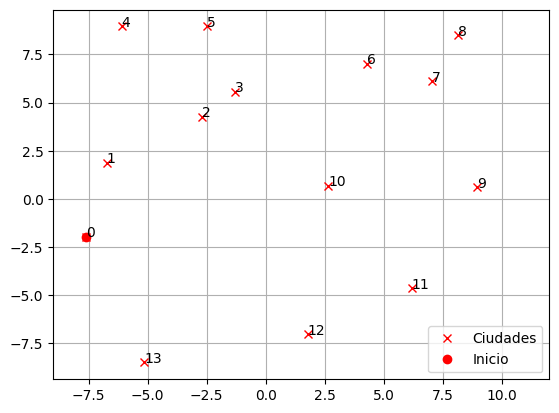

In [1]:
coordenadas = [
  [-7.5984,-1.9725],
  [-6.7323, 1.8807],
  [-2.7165, 4.2661],
  [-1.2992, 5.5505],
  [-6.1024, 8.9450],
  [-2.4803, 8.9450],
  [ 4.2913, 7.0183],
  [ 7.0472, 6.1009],
  [ 8.1496, 8.4862],
  [ 8.9370, 0.5963],
  [ 2.6378, 0.6881],
  [ 6.1811,-4.6330],
  [ 1.7717,-7.0183],
  [-5.1575,-8.4862]
]

x = [c[0] for c in coordenadas]
y = [c[1] for c in coordenadas]
import matplotlib.pyplot as plt
plt.plot(x, y, 'xr', label='Ciudades');
plt.plot(x[0], y[0], 'or', label='Inicio');
for i in range(len(coordenadas)):
    plt.text(x[i], y[i], i)
plt.legend()
plt.grid()
plt.xlim([-9,12])
print("Ciudades para el problema de TSP")

El algoritmo requiere conocer las distancias entre las ciudades para poder calcular la distancia total recorrida. Para ello se propone la siguiente funcion para calcular la distancia entre una ciudad *i* y *j*:

In [2]:
import math
def distancia(coord_i, coord_j):
  #distancia Euclidea
  return math.sqrt((coord_i[0]-coord_j[0])**2 + (coord_i[1]-coord_j[1])**2)

#ejemplo
ciudad_i = 1
ciudad_j = 5
d = distancia(coordenadas[ciudad_i], coordenadas[ciudad_j])
print("Distancia entre ciudad %d y %d; %f"%(ciudad_i, ciudad_j, d))

Distancia entre ciudad 1 y 5; 8.245231


In [3]:
# Operadores adicionales

def mut_swap(p, Bounds, n=1):
    m = p.copy()
    #genero permutacion al azar para elegir coordenadas distintas al azar
    r = list(range(len(m)-1))  #r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    o = r[:n]
    #indices de coordenadas destino
    d = r[n:2*n]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_adjoin_swap(p, Bounds, n=1):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir coordenadas distintas al azar
    r = list(range(len(m)-1))  #r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    o = r[:n]
    #indices de coordenadas destino
    d = [(x + 1) for x in o]  #d = [(x + 1) % len(m) for x in o]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_inversion(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[o[-i-1]]
    return m

def mut_shift_left(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #indices de coordenadas destino
    d = [x + 1 for x in o]  #d = [(x + 1) % len(m) for x in o]
    d[-1] = o[0]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
    return m

def mut_shift_right(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #indices de coordenadas destino
    d = [x - 1 for x in o]  #d = [(x - 1) % len(m) for x in o]
    d[0] = o[-1]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
    return m

def xov_partial_map(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1);
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(n))
    random.shuffle(r)
    #creo la mascara
    mask = [0]*n
    for i in range(min(r[:2]), max(r[:2])):
        mask[i] = 1
    #tacho valores que estan en p1 y p2
    m1 = [1]*n
    m2 = [1]*n
    for i in range(n):
        if not mask[i]:
            for j in range(n):
                if p1[i] == p2[j]:
                    m1[j] = 0
                if p2[i] == p1[j]:
                    m2[j] = 0
    j = k = 0
    #pongo calores no tachados en c1 y c2
    for i in range(n):
        if mask[i]:
            print(f'J: {j}')
            print(f'm[J]: {m1[j] == 0}')
            while m1[j] == 0 or j >= len(m1):
                j += 1
            while m2[k] == 0 or k >= len(m2):
                k += 1
            c1[i] = p2[j]
            c2[i] = p1[k]
            j += 1
            k += 1
    return c1, c2

def xov_order_based(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)
    #crear mascara al azar
    mask = [random.randint(0,1) for i in range(n)]
    #tacho valores que estan en p1 y p2
    m1 = [1]*n
    m2 = [1]*n
    for i in range(n):
        if not mask[i]:
            for j in range(n):
                if p1[i] == p2[j]:
                    m1[j] = 0
                if p2[i] == p1[j]:
                    m2[j] = 0
    j = k = 0
    #pongo calores no tachados en c1 y c2
    for i in range(n):
        if mask[i]:
            while m1[j] == 0:
                j += 1
            while m2[k] == 0:
                k += 1
            c1[i] = p2[j]
            c2[i] = p1[k]
            j += 1
            k += 1
    return c1, c2

def xov_scattered_crossover(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)
    #crear mascara al azar
    mask = [1 if (i % 2 == 0) else 0 for i in range(n)]
    random.shuffle(mask)
    for i in range(n):
        if (mask[i]):
            c1[i] = p2[i]
            c2[i] = p1[i]
        else:
            c1[i] = p1[i]
            c2[i] = p2[i]
    return c1, c2

def sel_ruleta(F, cant_selectos, eps):
    """ Operador de selección por torneos.
    Parametros:
    F: list. Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int. Cantidad de individuos a seleccionar.
    eps: int. valor para normalizar el fitness.
    S: list. Lista con las posiciones de los individuos seleccionados.
    """

    S = []
    min_valor = min(F)
    lista_ajustada = [(x - min_valor + eps) for x in F] #hacemos que sean todos positivos y mayores a cero
    suma = sum(lista_ajustada)
    pesos = [(x / suma) for x in lista_ajustada]
    puntos_de_corte = [(sum(pesos[:i+1])) for i in range(len(pesos))]
    tiros = [random.random() for i in range(cant_selectos)]
    for tiro in tiros:
        for i in range(len(puntos_de_corte)):
            if tiro < puntos_de_corte[i]:
                S.append(i)
                break

    return S


def sel_sus(F, cant_selectos, eps):
    """ Operador de seleccion stochastic universal sampling (SUS).
    Parametros:
    F: list. Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int. Cantidad de individuos a seleccionar.
    eps: int. valor para normalizar el fitness (no lo estoy usando).
    S: list. Lista con las posiciones de los individuos seleccionados.
    """
    tot_fit = sum(F)
    lista_prob = [fit/tot_fit for fit in F]
    lista_prob_acum = [lista_prob[i] if i == 0 else lista_prob[i] + sum(lista_prob[:i]) for i in range(len(lista_prob))]
    random_num = random.uniform(0, (1 / cant_selectos))
    tiros = [random_num + i * (1 / cant_selectos) for i in range(cant_selectos)]
    # for tiro in tiros:
    #     if tiro <
    contador = 0
    i = 0
    j = 0
    S = []
    while contador < cant_selectos:
        if tiros[j] < lista_prob_acum[i]:
            S.append(i)
            contador += 1
            j += 1
        else:
            i +=1

    return S

Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base al objetivo del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidades de ciudades.

In [4]:

import matplotlib.pyplot as plt
import random
import numpy as np
import itertools
import sympy as sp
from shapely.geometry import LineString, Point

def geneticoTsp(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, mut2, \
                   cant_cruzados, cant_mutados, cant_mutados2, cant_elite, param_sel, f, coordenadas, \
                   fitness_weight, intersections_weight, measure_intersections, callback=None):
    """
    Algoritmo Genetico Simple
    Parametros:
    - Pop: list. poblacion inicial (lista de listas).
    - cant_generac: int. Cantidad de iteraciones del algoritmo. Usamos cantidad de generaciones sin mejora
    - Bounds: list: Matriz que indica los valores max y min de cada variable.
    - Enteras: list. Vector booleano que indica si las coordenadas son enteras.
    - cant_cruzados: int. Cantidad de individuos que seran cruzados.
    - cant_mutados: int. Cantidad de soluciones a las cuales se le aplicara
      mutacion.
    - cant_elite: int. Numero de mejores soluciones que pasan a la siguiente
      generacion sin cambio alguno.
    - param_sel: float. Parametro usado en la seleccion, por ejemplo el peso que
      se le asigna a la solucion menos probable en el calculo de la probabilidad
      para ruleta. En caso de usar torneo, este es el tamano del torneo.
    - f: function. Funcion de evaluacion. Debe recibir como parametro un vector
      solucion y devolver un numero real.
    - intersections_weight: Un peso en distancia para las intersecciones en el recorrido
    - measure_intersections: Si tengo en cuenta la penalidad por usar intersecciones
    - callback: function. Funcion que se ejecuta una vez en cada iteracion (para
      mostrar resultados parciales). Usar None para deshabilitarla.
    Salida
    - soluc: list. Vector solucion que obtuvo fitness mas alto.
    - solF: float. Valor de evaluacion de la mejor solucion.
    - Pop: list. Poblacion final.
    - Fit: list. Fitness de cada individuo de la poblacion final.
    - traceBest: list. Vector con los mejores valores de fitness obtenidos en
      cada generacion. Se puede utilizar para determinar si el algoritmo
      llego a crowding.
    - traceAvg: list. Vector con los valores promedio de fitness
      obtenidos en cada generacion.
    """
    #inicializacion
    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor = 0
    cant_intentos_malos = 0
    #mejor conserva el valor de la mejor solucion
    #cant_intentos malos va acumulando y sera mi condicion de parada.

    #verifico los parametros de entrada
    if cant_soluc < 2:
        print('La Poblacion debe tener al menos dos individuos.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print('El tamano de la matriz Bounds es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print('El tamano del vector Enteras es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print('La cantidad de cruzados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print('La cantidad de mutados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite >= cant_soluc:
        print('El tamano de la elite debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    #inicializo variables para reducir tiempo de calculo
    cb_param = None
    p = [i for i in range(cant_soluc)]

    #realizo las evaluaciones de la poblacion inicial.
    for k in range(cant_soluc):
        #Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
        Fit[k] = f(Pop[k], coordenadas, fitness_weight,intersections_weight, measure_intersections)
    #if callback != None:
     #   cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)
    #obtengo el orden de los individuos
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor = Fit[p_orden[0]]


    while(True):
        # print(f'Generacion: {gen}')
        #selecciono la elite de la generacion actual (una copia)
        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #seleccion
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        #cruzamiento
        random.shuffle(p)
        for k in range(0, cant_cruzados-1, 2):
            C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in C1]
            Pop[p[k+1]] = [xi for xi in C2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #mutacion
        random.shuffle(p)
        for k in range(cant_mutados):
            C = mut(Pop[p[k]], Bounds)
            Pop[p[k]] = [xi for xi in C]
            Fit[p[k]] = None

        #mutacion2
        random.shuffle(p)
        for k in range(cant_mutados2):
            C2 = mut2(Pop[p[k]], Bounds)
            Pop[p[k]] = [xi for xi in C2]
            Fit[p[k]] = None


        #inserto la elite en la nueva poblacion en lugares al azar
        random.shuffle(p)
        for k in range(cant_elite):
            Pop[p[k]] = Elite[k]
            Fit[p[k]] = Elite_Fit[k]

        #realizo las evaluaciones de la nueva generacion
        for k in range(cant_soluc):
            if Fit[k] == None:
                Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
                Fit[k] = f(Pop[k], coordenadas, fitness_weight,intersections_weight, measure_intersections)

        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)


        #datos estadisticos
        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if mejor >= Fit[p_orden[0]]:
          cant_intentos_malos += 1
        else:
          cant_intentos_malos = 0
          mejor = Fit[p_orden[0]]

        if cant_intentos_malos >= cant_generac:
          solF = Fit[p_orden[0]]
          sol = Pop[p_orden[0]]
          return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols


        #funcion para graficar, mostrar, etc.
        if callback != None:
            cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

    #busco la mejor solucion obtenida
    # solF = Fit[p_orden[0]]
    # sol = Pop[p_orden[0]]
    # #graficar_generacion(Pop)

    # return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

def graficarEvolucionFitness(best, mean):
    """Método para graficar la evolucion del fitness con las iteraciones.
    Parametros
    best, mean : list. Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = range(len(best))
    plt.plot(x, best, label='Mejor solución')
    plt.plot(x, mean, label='Promedio poblacion')
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()
    plt.show()

def create_array_base(num_ciudades, punto_inicial):
    array_base = list(range(0, num_ciudades))
    array_base.remove(punto_inicial)
    random.shuffle(array_base)
    return array_base

def init_pop_tsp(num_ciudades, punto_inicial, cantidad_individuos, Bounds):
    return [create_array_base(num_ciudades, punto_inicial) for i in range(cantidad_individuos)]

import math
def distancia(coord_i, coord_j):
  #distancia Euclidea
  return math.sqrt((coord_i[0]-coord_j[0])**2 + (coord_i[1]-coord_j[1])**2)


def funcion_evaluacion(individuo, coordenadas):
    dist_total = sum(distancia(coordenadas[individuo[i]], coordenadas[individuo[i+1]]) for i in range(len(individuo) - 1))


    return dist_total


def penalizacion_por_interseccion(individuo, measure_intersections):
    if measure_intersections:
         intersections = count_intersections(get_routes_info(individuo, coordenadas))
         #print(len(intersections))

    return len(intersections) if len(intersections) > 0 else 0

def g_solucion(individuo, coordenadas, fitness_weight = 1, intersections_weight= 30, measure_intersections=False):
  individuoCompleto = individuo.copy()
  individuoCompleto.append(0)
  individuoCompleto.insert(0,0)
  penalizacion = intersections_weight * penalizacion_por_interseccion(individuoCompleto, measure_intersections)
  evaluacion = fitness_weight * funcion_evaluacion(individuoCompleto, coordenadas)

  return (1/((evaluacion + penalizacion) ** 2))


def graficar_recorrido(ciudades_list, intersections):
    x = [coordenadas[i][0] for i in ciudades_list]
    y = [coordenadas[i][1] for i in ciudades_list]
    intersections_x = [i[0] for i in intersections]
    intersections_y = [i[1] for i in intersections]
    plt.plot(x, y, label='Recorrido');
    plt.plot(x, y, 'xr', label='Ciudades');
    plt.plot(intersections_x, intersections_y, 'xk', label='Intersecciones');
    plt.plot(x[0], y[0], 'or', label='Inicio');
    for i in range(len(coordenadas)):
        plt.text(coordenadas[i][0], coordenadas[i][1], i)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid()
    plt.xlim([-9,12])
    print("Ciudades para el problema de TSP")
    plt.show()

def get_routes_info(individuo, coordenadas):

    r = []
    for i in range(len(individuo) - 1):
        try:
            slope = (coordenadas[individuo[i+1]][1] - coordenadas[individuo[i]][1]) / (coordenadas[individuo[i+1]][0] - coordenadas[individuo[i]][0])
        except ZeroDivisionError:
            slope = 0
        r.append([[coordenadas[individuo[i]][0], coordenadas[individuo[i]][1]],
         [coordenadas[individuo[i+1]][0], coordenadas[individuo[i+1]][1]], slope, i, i+1])
    return r

def count_intersections(segments):
    intersection_points = []

    for seg1, seg2 in itertools.combinations(segments, 2):
        point = find_segment_intersection_v2(seg1, seg2)

        if point is not None:
            # print(f'Hay una interseccion entre el segmento {seg1[3]}-{seg1[4]} y el segmento {seg2[3]}-{seg2[4]}')
            # print(f'En el punto: X-{point[0]} - Y-{point[1]}')
            intersection_points.append([point[0], point[1]])

    return intersection_points

def find_segment_intersection(rec1, rec2):
    (x1, y1), (x2, y2), slope1, _, _ = rec1
    (x3, y3), (x4, y4), slope2, _, _ = rec2

    x, y = sp.symbols('x y')

    rs1 = slope1 * x1 - y1
    rs2 = slope2 * x3 - y3

    eq1 = sp.Eq(slope1*x - 1*y, rs1)

    eq2 = sp.Eq(slope2*x - 1*y, rs2)

    solucion = sp.solve((eq1, eq2), (x, y))

    if min(x1, x2) < round(solucion[x], 4) < max(x1, x2) and min(x3, x4) < round(solucion[x], 4) < max(x3, x4):
        if min(y1, y2) < round(solucion[y], 4) < max(y1, y2) and min(y3, y4) < round(solucion[y], 4) < max(y3, y4):
            if min(x1, x2) != int(solucion[x] * 10000) / 10000 and max(x1, x2) != int(solucion[x] * 10000) / 10000:
                if min(y1, y2) != int(solucion[y] * 10000) / 10000 and max(y1, y2) != int(solucion[y] * 10000) / 10000:
                    # print(f'Interseccion: {solucion}')

                    # print(f'Limites en y: {min(y1, y2)} - {max(y1, y2) }')
                    # print(f'Limites en x: {min(x1, x2)} - {max(x1, x2)}')

                    return [solucion[x], solucion[y]]
                else:
                    return None

def find_segment_intersection_v2(rec1, rec2):
    (x1, y1), (x2, y2), slope1, _, _ = rec1
    (x3, y3), (x4, y4), slope2, _, _ = rec2

    l1 = LineString([(x1, y1), (x2, y2)])
    l2 = LineString([(x3, y3), (x4, y4)])

    intersection = l1.intersection(l2)

    if isinstance(intersection, Point):
        if min(x1, x2) != int(intersection.x * 10000) / 10000 and max(x1, x2) != int(intersection.x * 10000) / 10000:
                if min(y1, y2) != int(intersection.y * 10000) / 10000 and max(y1, y2) != int(intersection.y * 10000) / 10000:
                    # print(f'X: {intersection.x}')
                    # print(f'Y: {intersection.y}')
                    return [intersection.x, intersection.y]
                else:
                    return None

La menor distancia posible es 71.36208073980058


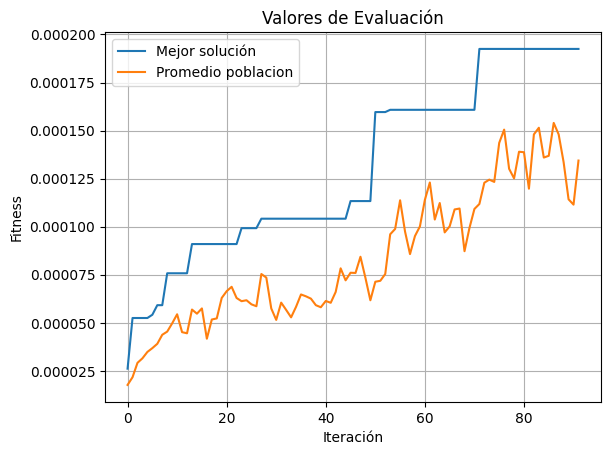

Mejor solución: [0, 1, 2, 3, 4, 5, 6, 8, 7, 10, 9, 11, 12, 13, 0] (Fitness: 72.07742919889395)
Hay 0 intersecciones


In [22]:

coordenadas = [
  [-7.5984,-1.9725],
  [-6.7323, 1.8807],
  [-2.7165, 4.2661],
  [-1.2992, 5.5505],
  [-6.1024, 8.9450],
  [-2.4803, 8.9450],
  [ 4.2913, 7.0183],
  [ 7.0472, 6.1009],
  [ 8.1496, 8.4862],
  [ 8.9370, 0.5963],
  [ 2.6378, 0.6881],
  [ 6.1811,-4.6330],
  [ 1.7717,-7.0183],
  [-5.1575,-8.4862]
]
# coordenadas = [
#     [0,0],
#     [1,0],
#     [1,2],
#     [3,2],
#     [3,5],
# ]



Bounds = [[1, len(coordenadas) - 1] for i in range(len(coordenadas)-1)]  #ciudades del 2 al 14

Enteras = [True]* (len(coordenadas)-1)
f = g_solucion
cant_individuos = 10
cant_generac = 20
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_order_based
cant_cruzados = round(0.7 * cant_individuos)
mut = mut_inversion
cant_mutados = round(0.4 * cant_individuos)
mut2 = mut_swap
cant_mutados2 = round(0.15* cant_individuos)
callback = None #usar None para que no grafique y vaya mas rapido

measure_intersections = True
intersections_weight = 5
fitness_weight = 1


mejor_ruta =[1, 4, 5, 2, 3, 6, 8, 7, 9, 10, 11, 12, 13]
#mejor_ruta =[1, 3, 5, 2, 4, 6, 8, 7, 9, 10, 11, 12, 13]
print(f'La menor distancia posible es {math.sqrt(1 / (g_solucion(mejor_ruta, coordenadas,fitness_weight,intersections_weight, measure_intersections=True)))}')

Pop = init_pop_tsp(len(coordenadas), 0, cant_individuos, Bounds)

sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
    geneticoTsp(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, mut2,\
        cant_cruzados, cant_mutados,cant_mutados2, cant_elite, eps, f, coordenadas,\
                   fitness_weight, intersections_weight, measure_intersections, callback)

graficarEvolucionFitness(traceBest, traceAvg)
sol.append(0)
sol.insert(0,0)
print("Mejor solución: {0} (Fitness: {1})".format(sol, math.sqrt(1/(solF))))
print(f'Hay {len(count_intersections(get_routes_info(sol, coordenadas)))} intersecciones')


Ciudades para el problema de TSP


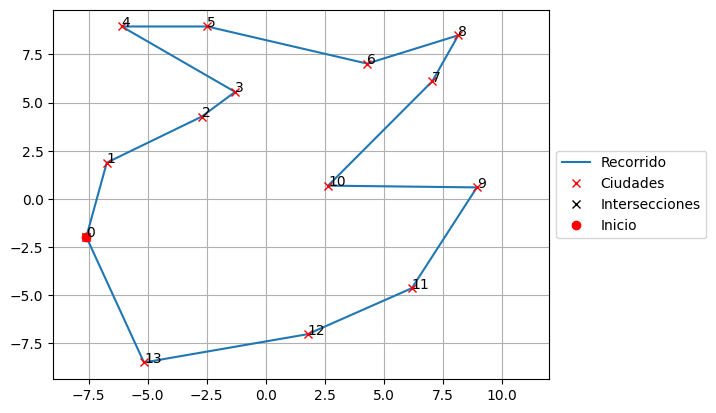

In [23]:
intersections = count_intersections(get_routes_info(sol, coordenadas))
graficar_recorrido(sol, intersections)


## Ejercicio 2

Se tiene una red de distribución eléctrica como la de la Figura, compuesta por un transformador trifásico que alimenta a N=20 clientes monofásicos. Un cliente solo puede estar conectado a una fase.

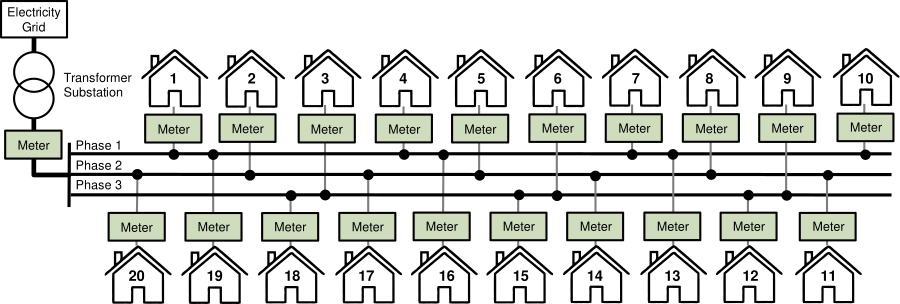








Cada cliente cuenta con un medidor inteligente que registra cuánta energía ha consumido durante un mes. Los valores de consumo son los siguentes:




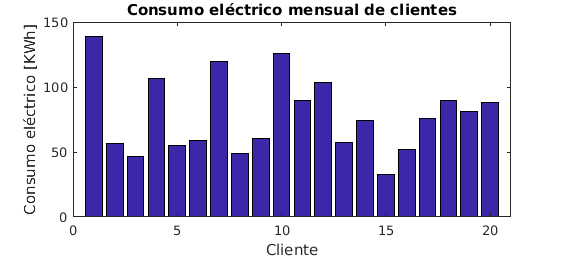




La energía total registrada en la fase "i" del transformador puede ser calculada sumando la energía consumida por todos los clientes conectados a dicha fase. Los consumos por fase son:




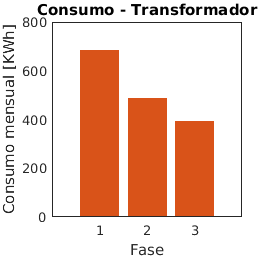




Debido a que existe una gran diferencia de consumo entre las fases, pueden ocurrir pérdidas de energía y se reduce la calidad del servicio eléctrico, entre otros inconvenientes.

Se pide resolver el problema de balance de carga, el cual consiste en equilibrar el valor del consumo eléctrico en cada una de las fases. Para lograrlo se pude cambiar de fase a algunos clientes. Dicho en otras palabras, se pide encontrar un nuevo esquema de conexión, de manera tal que el consumo total en cada fase sea aproximadamente el mismo.

Resuelva las siguientes dos variantes del problema:
1.  Teniendo en cuenta sólo reducir el desbalance de cargas en el transformador.
2.  Teniendo en cuenta reducir el desbalance con la mínima cantidad de cambios de fase.

Se pide:
*   Determine qué codificación utilizará para el problema (cómo representará las soluciones).
*   Diseñe una función de evaluación.
*   Seleccione los operadores genéticos adecuados para el problema.
*   Utilice un AG simple para encontrar una solución al problema.



In [11]:
import matplotlib.pyplot as plt
import random
import numpy as np
import itertools
import sympy as sp
from shapely.geometry import LineString, Point

def geneticoDesbalanceFases(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, mut2,\
                   cant_cruzados, cant_mutados, cant_mutados2, cant_elite, param_sel, f, \
                   desbalance_weight, cambio_de_fase_weight, fases_iniciales, callback=None):
    """
    Algoritmo Genetico Simple
    Parametros:
    - Pop: list. poblacion inicial (lista de listas).
    - cant_generac: int. Cantidad de iteraciones del algoritmo. Usamos cantidad de generaciones sin mejora
    - Bounds: list: Matriz que indica los valores max y min de cada variable.
    - Enteras: list. Vector booleano que indica si las coordenadas son enteras.
    - cant_cruzados: int. Cantidad de individuos que seran cruzados.
    - cant_mutados: int. Cantidad de soluciones a las cuales se le aplicara
      mutacion.
    - cant_elite: int. Numero de mejores soluciones que pasan a la siguiente
      generacion sin cambio alguno.
    - param_sel: float. Parametro usado en la seleccion, por ejemplo el peso que
      se le asigna a la solucion menos probable en el calculo de la probabilidad
      para ruleta. En caso de usar torneo, este es el tamano del torneo.
    - f: function. Funcion de evaluacion. Debe recibir como parametro un vector
      solucion y devolver un numero real.
    - intersections_weight: Un peso en distancia para las intersecciones en el recorrido
    - measure_intersections: Si tengo en cuenta la penalidad por usar intersecciones
    - callback: function. Funcion que se ejecuta una vez en cada iteracion (para
      mostrar resultados parciales). Usar None para deshabilitarla.
    Salida
    - soluc: list. Vector solucion que obtuvo fitness mas alto.
    - solF: float. Valor de evaluacion de la mejor solucion.
    - Pop: list. Poblacion final.
    - Fit: list. Fitness de cada individuo de la poblacion final.
    - traceBest: list. Vector con los mejores valores de fitness obtenidos en
      cada generacion. Se puede utilizar para determinar si el algoritmo
      llego a crowding.
    - traceAvg: list. Vector con los valores promedio de fitness
      obtenidos en cada generacion.
    """
    #inicializacion
    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor = 0
    cant_intentos_malos = 0
    #mejor conserva el valor de la mejor solucion
    #cant_intentos malos va acumulando y sera mi condicion de parada.

    #verifico los parametros de entrada
    if cant_soluc < 2:
        print('La Poblacion debe tener al menos dos individuos.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print('El tamano de la matriz Bounds es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print('El tamano del vector Enteras es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print('La cantidad de cruzados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print('La cantidad de mutados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite >= cant_soluc:
        print('El tamano de la elite debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    #inicializo variables para reducir tiempo de calculo
    cb_param = None
    p = [i for i in range(cant_soluc)]

    #realizo las evaluaciones de la poblacion inicial.
    for k in range(cant_soluc):
        #Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
        Fit[k] = f(Pop[k],  desbalance_weight, cambio_de_fase_weight)
    #if callback != None:
     #   cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)
    #obtengo el orden de los individuos
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor = Fit[p_orden[0]]


    while(True):
        # print(f'Generacion: {gen}')
        #selecciono la elite de la generacion actual (una copia)
        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #seleccion
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        #cruzamiento
        random.shuffle(p)
        for k in range(0, cant_cruzados-1, 2):
            C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in C1]
            Pop[p[k+1]] = [xi for xi in C2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #mutacion
        random.shuffle(p)
        for k in range(cant_mutados):
            C = mut(Pop[p[k]], Bounds)
            Pop[p[k]] = [xi for xi in C]
            Fit[p[k]] = None

          #mutacion2
        random.shuffle(p)
        for k in range(cant_mutados2):
            C2 = mut2(Pop[p[k]], Bounds)
            Pop[p[k]] = [xi for xi in C2]
            Fit[p[k]] = None


        #inserto la elite en la nueva poblacion en lugares al azar
        random.shuffle(p)
        for k in range(cant_elite):
            Pop[p[k]] = Elite[k]
            Fit[p[k]] = Elite_Fit[k]

        #realizo las evaluaciones de la nueva generacion
        for k in range(cant_soluc):
            if Fit[k] == None:
                Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
                Fit[k] = f(Pop[k], desbalance_weight, cambio_de_fase_weight)

        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)


        #datos estadisticos
        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if mejor >= Fit[p_orden[0]]:
          cant_intentos_malos += 1
        else:
          cant_intentos_malos = 0
          mejor = Fit[p_orden[0]]

        if cant_intentos_malos >= cant_generac:
          solF = Fit[p_orden[0]]
          sol = Pop[p_orden[0]]
          return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols


        #funcion para graficar, mostrar, etc.
        if callback != None:
            cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

    #busco la mejor solucion obtenida
    # solF = Fit[p_orden[0]]
    # sol = Pop[p_orden[0]]
    # #graficar_generacion(Pop)

    # return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

def graficarEvolucionFitness(best, mean):
    """Método para graficar la evolucion del fitness con las iteraciones.
    Parametros
    best, mean : list. Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = range(len(best))
    plt.plot(x, best, label='Mejor solución')
    plt.plot(x, mean, label='Promedio poblacion')
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()
    plt.show()

In [12]:

import random

#lista con valores de consumo para cada cliente.
consumos_iniciales = [138.49, 56.85, 46.56, 106.58, 54.62, 58.88, 119.36, 49.01, 60.48, 126.07, 89.31, 103.11, 57.18, 74.37, 32.46, 52.30, 75.53, 89.57, 81.36, 88.20]

#lista con valor de la fase donde se conecta el cliente.
fases_iniciales = [1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2]

def consumo_fases(consumos_clientes, fases_clientes):
    # Calcular el consumo total por fase a partir del consumo de clientes.
    # Parametros
    # - consumos_clientes: lista con valores de consumo para cada cliente.
    # - fases_clientes: lista con valor de la fase donde se conecta el cliente (valores 1,2 o 3).
    # - Devuelve vector con 3 elementos.

    consumos_fases = [0, 0, 0]
    for i, c in enumerate(consumos_clientes):
        consumos_fases[fases_clientes[i]-1] += c
    return consumos_fases


def indice_desbalance(consumo_fases):
    # Calcula el indice para medir el desbalance de las fases (más alto, más desbalanceado)
    media = sum(consumo_fases) / 3
    max_desviacion = 0
    for consumo in consumo_fases:
        if abs(consumo - media) > max_desviacion:
            max_desviacion = abs(consumo - media)
    return (max_desviacion / (sum(consumo_fases)/3)) * 100


def fitness_balance_carga(solucion, desbalance_weight, cambios_de_fase_weight):

    return 1 / ((indice_desbalance(consumo_fases(consumos_iniciales, solucion)) * desbalance_weight + count_cambios_de_fase(solucion, fases_iniciales) ** cambios_de_fase_weight)**2)


def create_array_base_transformadores(fase_inicial):
    array_base = [random.randint(1, 3) for i in range(len(fase_inicial))]
    return array_base

def init_pop_fases(cantidad_individuos, fases_iniciales):
    return [create_array_base_transformadores(fases_iniciales) for i in range(cantidad_individuos)]

def count_cambios_de_fase(individuo, fases_iniciales):
    cambios_de_fase = 0
    for i in range(len(individuo)):
        if individuo[i] != fases_iniciales[i]:
            cambios_de_fase += 1
    return cambios_de_fase

def carga_fase(individuo, fase, consumos_iniciales):
    carga = 0
    for i in range(len(individuo)):
        if individuo[i] == fase:
            carga += consumos_iniciales[i]
    return carga

def graficar_cargas_fases(individuo, consumos_iniciales, titulo):
    fases = [1, 2, 3]
    consumo_por_fase = [carga_fase(individuo, fase, consumos_iniciales) for fase in fases]
    equilibrio = np.mean(consumo_por_fase)
    plt.figure(figsize=(4, 4))
    plt.bar(fases, consumo_por_fase, color='orangered', width=0.6)

    # Línea horizontal de equilibrio
    plt.axhline(equilibrio, color='blue', linestyle='--', linewidth=1.2,
                label=f'Equilibrio ({equilibrio:.0f} kWh)')

    # Etiquetas
    plt.title(titulo, fontweight="bold")
    plt.xlabel("Fase")
    plt.ylabel("Consumo mensual [kWh]")
    plt.legend()
    plt.tight_layout()

    plt.show()


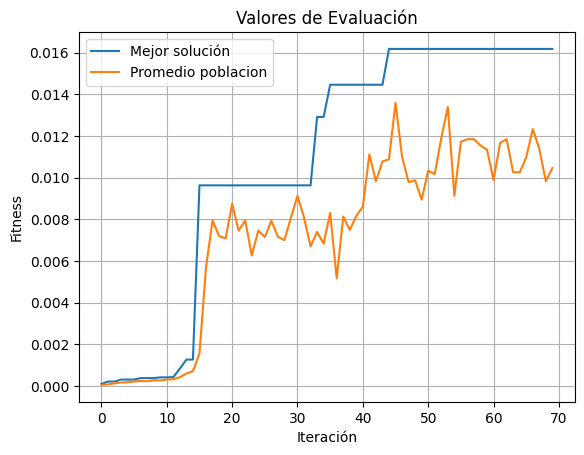

Mejor solución: [1, 2, 3, 1, 2, 3, 3, 2, 3, 1, 2, 3, 1, 2, 3, 2, 2, 3, 1, 2] (Fitness: 61.83281376379319)
Se realizaron 2 cambios de fase
El desbalance de fases es de 3.8633843708541415%


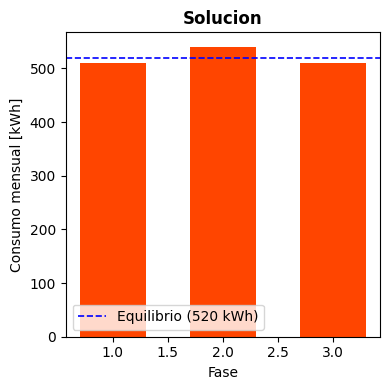

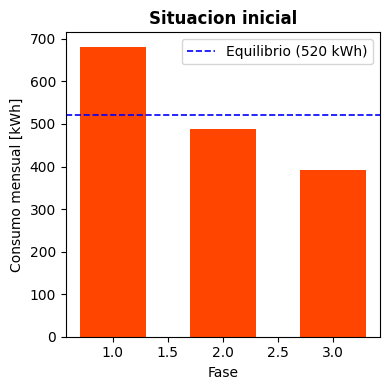

In [14]:
import math

Bounds = [[1, 3] for i in range(len(fases_iniciales))]

Enteras = [True] * (len(fases_iniciales))
f = fitness_balance_carga
cant_individuos = 10
cant_generac = 25
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_scattered_crossover
cant_cruzados = round(0.7* cant_individuos)
mut = mut_swap
cant_mutados = round(0.45 * cant_individuos)
mut2 = mut_inversion
cant_mutados2 = round(0.25 * cant_individuos)
callback = None #usar None para que no grafique y vaya mas rapido
# Mejor sol hasta ahora [1, 2, 3, 2, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 3, 3, 3, 1, 2]
desbalance_weight = 1
cambio_de_fase_weight = 2

Pop = init_pop_fases(cant_individuos, fases_iniciales)

sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
    geneticoDesbalanceFases(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, mut2,\
        cant_cruzados, cant_mutados, cant_elite,cant_mutados2, eps, f, desbalance_weight, \
        cambio_de_fase_weight, fases_iniciales, callback)

graficarEvolucionFitness(traceBest, traceAvg)
print("Mejor solución: {0} (Fitness: {1})".format(sol, 1/solF))
print(f'Se realizaron {count_cambios_de_fase(sol, fases_iniciales)} cambios de fase')
print(f'El desbalance de fases es de {indice_desbalance(consumo_fases(consumos_iniciales, sol))}%')

graficar_cargas_fases(sol, consumos_iniciales, "Solucion")
graficar_cargas_fases(fases_iniciales, consumos_iniciales, "Situacion inicial")
